<a href="https://colab.research.google.com/github/2023atharvvichare/Machine-Learning/blob/main/ML_Experiment6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


Shape of dataset: (1797, 64)
Number of classes: 10


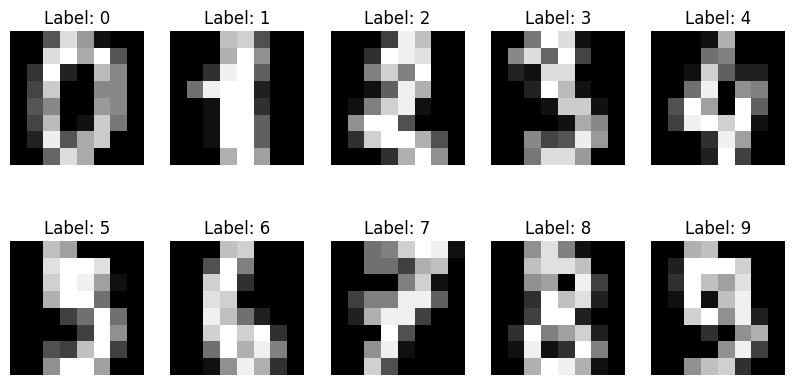

In [ ]:
digits = datasets.load_digits()

print("Shape of dataset:", digits.data.shape)
print("Number of classes:", len(np.unique(digits.target)))

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f"Label: {digits.target[i]}")
    ax.axis('off')
plt.show()


In [ ]:
X = digits.data / 16.0
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape, "Test set:", X_test.shape)


Training set: (1437, 64) Test set: (360, 64)


In [ ]:
svm_clf = SVC(kernel='rbf', gamma=0.001, C=10)
svm_clf.fit(X_train, y_train)

y_pred = svm_clf.predict(X_test)


In [ ]:
print(y_pred)

[5 2 8 1 7 2 6 2 6 5 0 5 9 3 4 4 2 4 9 9 6 3 8 1 2 5 6 0 3 4 6 7 2 6 6 6 8
 5 0 9 1 7 9 6 5 7 5 2 7 5 0 1 5 5 3 2 4 0 0 2 7 5 6 1 3 7 6 5 7 0 9 0 3 8
 2 5 7 2 3 5 9 3 2 7 9 6 1 1 0 1 2 9 4 7 1 2 7 8 4 2 6 9 3 7 3 9 6 9 1 0 9
 2 1 6 3 4 8 7 1 0 0 4 6 5 1 2 8 1 3 0 0 8 6 4 3 9 3 3 3 3 4 7 0 0 1 9 5 8
 1 5 0 6 6 6 6 1 7 7 6 7 7 8 7 3 6 5 9 0 3 8 0 9 1 1 9 5 9 5 8 9 9 7 9 1 9
 5 4 7 3 0 4 9 7 7 5 6 5 8 3 4 5 4 9 2 5 5 2 1 3 8 8 9 3 6 9 0 1 4 0 5 5 6
 6 7 4 3 8 4 5 0 7 9 2 1 4 8 4 2 4 0 0 0 2 6 7 0 4 5 2 2 9 0 4 6 8 2 3 9 2
 3 0 6 8 7 1 4 4 1 1 6 3 8 1 2 5 7 7 3 2 0 3 4 1 9 7 9 6 3 7 1 6 9 4 7 1 8
 1 3 0 5 3 4 1 9 3 5 4 7 4 1 5 1 5 0 9 8 4 2 3 8 4 1 2 0 1 1 4 4 5 7 5 0 3
 2 2 4 2 7 7 8 7 6 3 1 1 5 8 8 8 6 7 2 7 8 9 4 2 0 3 4]


Accuracy: 0.9583

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.85      0.92      0.88        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       0.97      1.00      0.99        36
           5       0.97      1.00      0.99        37
           6       1.00      0.97      0.99        36
           7       0.90      1.00      0.95        36
           8       0.96      0.77      0.86        35
           9       0.94      0.94      0.94        36

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360



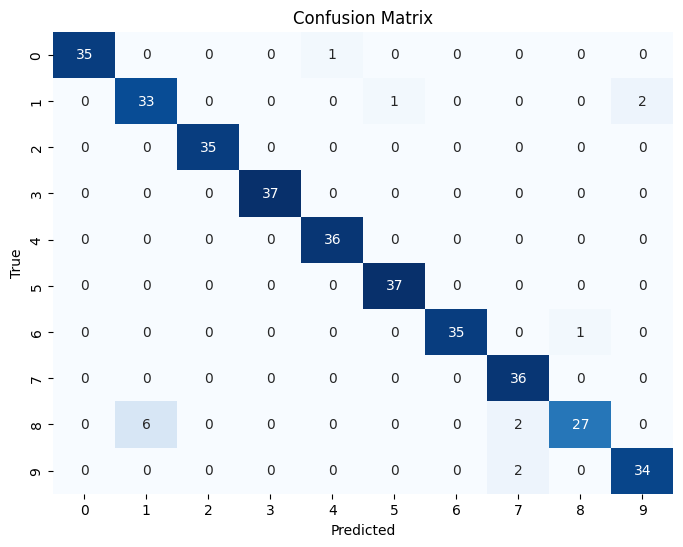

In [ ]:

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


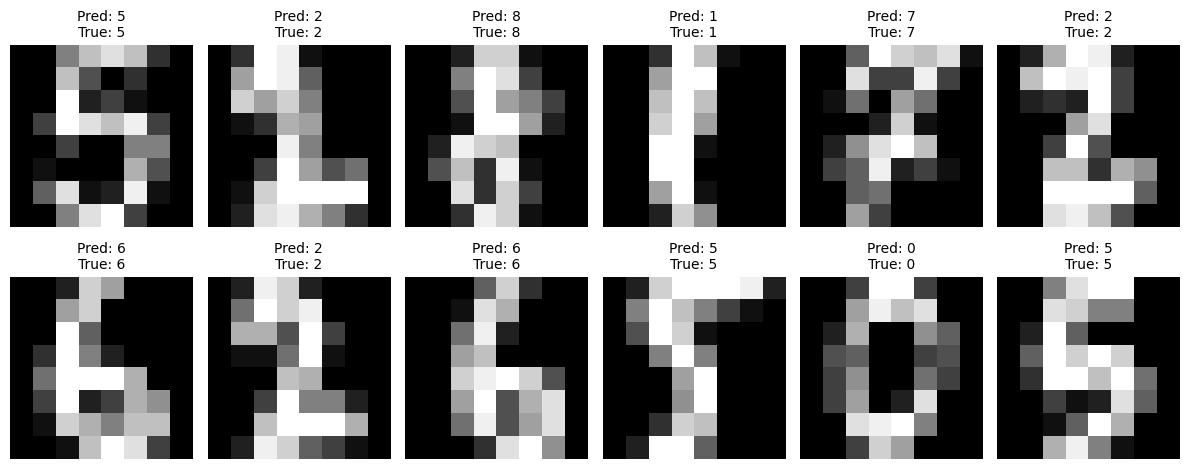

In [ ]:
fig, axes = plt.subplots(2, 6, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(8,8), cmap='gray')
    ax.set_title(f"Pred: {y_pred[i]}\nTrue: {y_test[i]}", fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()


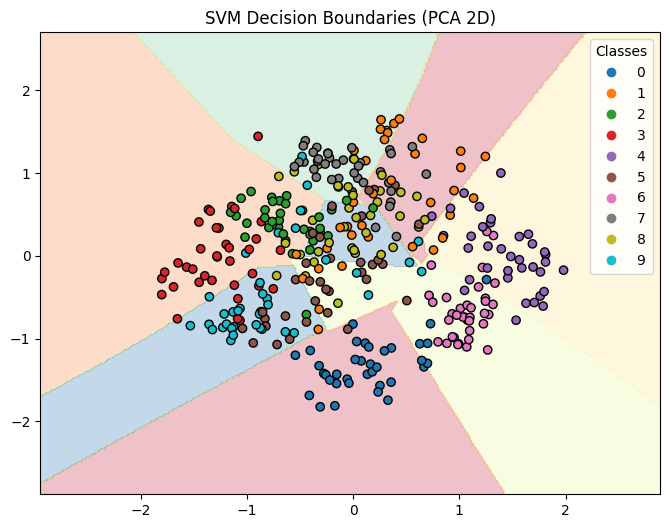

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42, stratify=y
)

svm_2d = SVC(kernel='rbf', gamma=0.01, C=10)
svm_2d.fit(X_train_r, y_train_r)


h = .02
x_min, x_max = X_train_r[:, 0].min() - 1, X_train_r[:, 0].max() + 1
y_min, y_max = X_train_r[:, 1].min() - 1, X_train_r[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.3)
scatter = plt.scatter(X_test_r[:, 0], X_test_r[:, 1], c=y_test_r, cmap=plt.cm.tab10, edgecolor='k')
plt.legend(*scatter.legend_elements(), title="Classes")
plt.title("SVM Decision Boundaries (PCA 2D)")
plt.show()
